In [108]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.metrics import accuracy_score
from sklearn.svm import SVR

In [109]:
df = pd.read_csv("house_prices_practice.csv")

In [110]:
df.head()

,Id,OverallQual,GrLivArea,GarageCars,TotalBsmtSF,YearBuilt,FullBath,BedroomAbvGr,LotArea,SalePrice
0,1,7,1560,0,1658,1969,2,1,8059,177106
1,2,4,2827,2,1319,2012,3,4,13530,301044
2,3,8,3920,0,841,2010,1,4,9010,360609
3,4,5,3044,0,1058,1998,0,4,13207,240556
4,5,7,801,1,2428,2020,0,1,9117,193656


In [111]:
df.isna().sum()

Id              0
OverallQual     0
GrLivArea       0
GarageCars      0
TotalBsmtSF     0
YearBuilt       0
FullBath        0
BedroomAbvGr    0
LotArea         0
SalePrice       0
dtype: int64

In [112]:
df.duplicated().sum()

np.int64(0)

In [113]:
x = df.drop(columns = ['Id', 'SalePrice'], axis=1)
y = df['SalePrice']

In [114]:
std = StandardScaler()

In [115]:
x_train, x_test, y_train, y_test = train_test_split(x, y, random_state=42, test_size=.2)

In [116]:
svr = SVR(kernel="linear")

In [ ]:
svr.fit(x_train, y_train)
print(svr.score(x_train, y_train))
print(svr.score(x_test, y_test))

-2.4590248666411796e-05
2.407035475160413e-06


In [ ]:
svr.intercept_

array([251580.1059237])

In [ ]:
param_grid = {
  "kernel" : ['linear', 'poly', 'rbf', 'sigmoid'],
  'degree' : [2,3,5],
  "gamma" : ["scale", "auto", .1 , .001, 1],
  'C' : [0.1, 1, 10, 100]
}

In [ ]:
grid_cv = RandomizedSearchCV(estimator=svr, param_distributions=param_grid, cv = 4, n_jobs=-1, verbose=10)

In [ ]:
# grid_cv.fit(x_train, y_train)

In [ ]:
df.head()

,Id,OverallQual,GrLivArea,GarageCars,TotalBsmtSF,YearBuilt,FullBath,BedroomAbvGr,LotArea,SalePrice
0,1,7,1560,0,1658,1969,2,1,8059,177106
1,2,4,2827,2,1319,2012,3,4,13530,301044
2,3,8,3920,0,841,2010,1,4,9010,360609
3,4,5,3044,0,1058,1998,0,4,13207,240556
4,5,7,801,1,2428,2020,0,1,9117,193656


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import ListedColormap

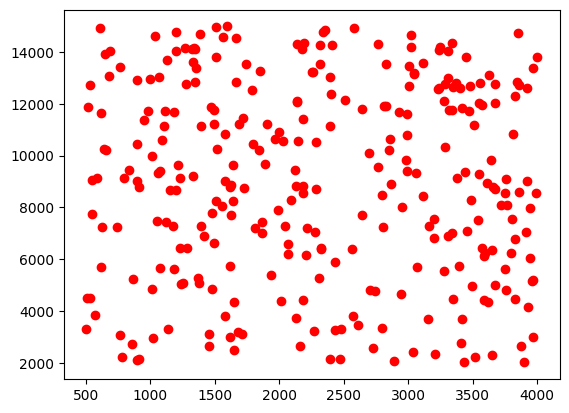

In [ ]:
plt.scatter(df['GrLivArea'], df['LotArea'], c="r")

In [ ]:
zero_one_colourmap = ListedColormap(['blue', 'red'])
def plot_decision_boundary(X, y, clf):
    X_set, y_set = X, y
    X1, X2 = np.meshgrid(np.arange(start = X_set[:, 0].min() - 1,
                                 stop = X_set[:, 0].max() + 1,
                                 step = 0.01),
                       np.arange(start = X_set[:, 1].min() - 1,
                                 stop = X_set[:, 1].max() + 1,
                                 step = 0.01))

    plt.contourf(X1, X2, clf.predict(np.array([X1.ravel(),
                                             X2.ravel()]).T).reshape(X1.shape),
               alpha = 0.75,
               cmap = zero_one_colourmap)
    plt.xlim(X1.min(), X1.max())
    plt.ylim(X2.min(), X2.max())
    for i, j in enumerate(np.unique(y_set)): # 0 0, 1 1
        plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],
                c = (zero_one_colourmap)(i), label = j)
    plt.title('SVM Decision Boundary')
    plt.xlabel('X1')
    plt.ylabel('X2')
    plt.legend()
    return plt.show()